# SE3 Imbalance — Spike Detection

Binary classifier (spike vs normal) for SE3 imbalance prices.

**Training config that produced AUC=0.899**:
- `class_weight={0:1.0, 1:25.0}`, `eval_metric="auc"`
- Window augmentation ±2 periods around real spikes
- Real validation holdout taken **before** window augmentation
- No SMOTE, no Platt calibration

**Targets**: Recall > 0.50 at cost threshold, F2 > 0.30, AUC-ROC > 0.75


In [1]:
import asyncio
if hasattr(asyncio, 'WindowsSelectorEventLoopPolicy'):
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

from __future__ import annotations

import logging
import os
import sys
import warnings
from datetime import date, timedelta
from pathlib import Path

import holidays
import lightgbm as lgb
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make notebooks/ importable regardless of cwd
_here = Path.cwd()
for _p in [_here / "notebooks", _here]:
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

from data_sources import merge_all_sources
from feature_engineering import (
    STRESS_HIGH, STRESS_LOW, EXTREME_HIGH, EXTREME_LOW,
    build_features, make_feature_cols, assign_spike_class, assign_normal_class,
)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

SE_HOLIDAYS = holidays.Sweden()
ENTSOE_KEY  = os.environ.get("ENTSOE_API_KEY", "")

FETCH_MONTHS = 18
TEST_DAYS    = 60
HORIZON      = 1   # 15-min periods

LGBM_PARAMS = dict(
    n_estimators=2000, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, feature_fraction=0.8,
    bagging_fraction=0.8, bagging_freq=5, verbose=-1,
)

print(f"ENTSOE key  : {bool(ENTSOE_KEY)}")
print(f"LightGBM    : {lgb.__version__}")
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay,
    precision_score, recall_score, fbeta_score,
)

FIGURES_DIR = Path("figures/spike_detection")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COST_FP = 15.0    # EUR/MWh false positive cost
COST_FN = 300.0   # EUR/MWh false negative (missed spike) cost

CLASS_NAMES = {0: "Normal", 1: "Stress", 2: "Extreme"}
print(f"Spike thresholds: > {STRESS_HIGH} or < {STRESS_LOW} EUR/MWh")
print(f"Cost threshold  : FP/(FP+FN) = {COST_FP/(COST_FP+COST_FN):.4f}")


ENTSOE key  : True
LightGBM    : 4.6.0
Spike thresholds: > 200.0 or < -100.0 EUR/MWh
Cost threshold  : FP/(FP+FN) = 0.0476


In [2]:
end_d   = date.today()
start_d = end_d - timedelta(days=int(FETCH_MONTHS * 30.5))

df_merged = merge_all_sources(start_d, end_d, entsoe_key=ENTSOE_KEY)
print(f"\nMerged: {df_merged.shape[0]:,} rows x {df_merged.shape[1]} cols")

# Class distribution in merged data
spike_cls_full = assign_spike_class(df_merged["imbl_price"])
for cls, name in CLASS_NAMES.items():
    n = (spike_cls_full == cls).sum()
    print(f"  Class {cls} ({name:<8}): {n:,} ({n/len(df_merged)*100:.2f}%)")
print(f"  Spike prevalence (1+2): {(spike_cls_full > 0).mean()*100:.2f}%")


DATA SOURCE STATUS


  OK  eSett imbalance             :  52,783 rows  2024-12-05 -> 2026-06-07


  OK  Open-Meteo archive          :  52,605 rows  2024-12-05 -> 2026-06-06


  OK  Open-Meteo hist. forecast   :  52,797 rows  2024-12-05 -> 2026-06-08
  OK  SMHI snow1g forecast        :     969 rows  2026-06-07 -> 2026-06-17
  OK  SMHI mesan2g analysis       :      93 rows  2026-06-06 -> 2026-06-07


  OK  Spot prices                 :  52,701 rows  2024-12-05 -> 2026-06-07


  OK  Nuclear unavailability      :  52,701 rows  2024-12-05 -> 2026-06-07


  OK  Generation forecast         :  52,701 rows  2024-12-05 -> 2026-06-07


  OK  Cross-border flows          :  31,241 rows  2024-12-05 -> 2026-06-06

MERGE REPORT
  Rows   : 52,783
  Cols   : 32
  Period : 2024-12-05 -> 2026-06-07

  imbalance             : 3 col(s),   0.1% null
  weather               : 3 col(s),   0.4% null
  spot                  : 1 col(s),   0.2% null
  fcst_hist             : 2 col(s),   0.0% null
  smhi_fcst_ovlay       : 2 col(s),  99.9% null
  smhi_analysis         : 2 col(s),  99.8% null
  nuclear               : 2 col(s),   0.2% null
  gen_forecast          : 2 col(s),   1.6% null
  flows                 : 1 col(s),  40.8% null

Merged: 52,783 rows x 32 cols
  Class 0 (Normal  ): 50,538 (95.75%)
  Class 1 (Stress  ): 2,074 (3.93%)
  Class 2 (Extreme ): 171 (0.32%)
  Spike prevalence (1+2): 4.25%


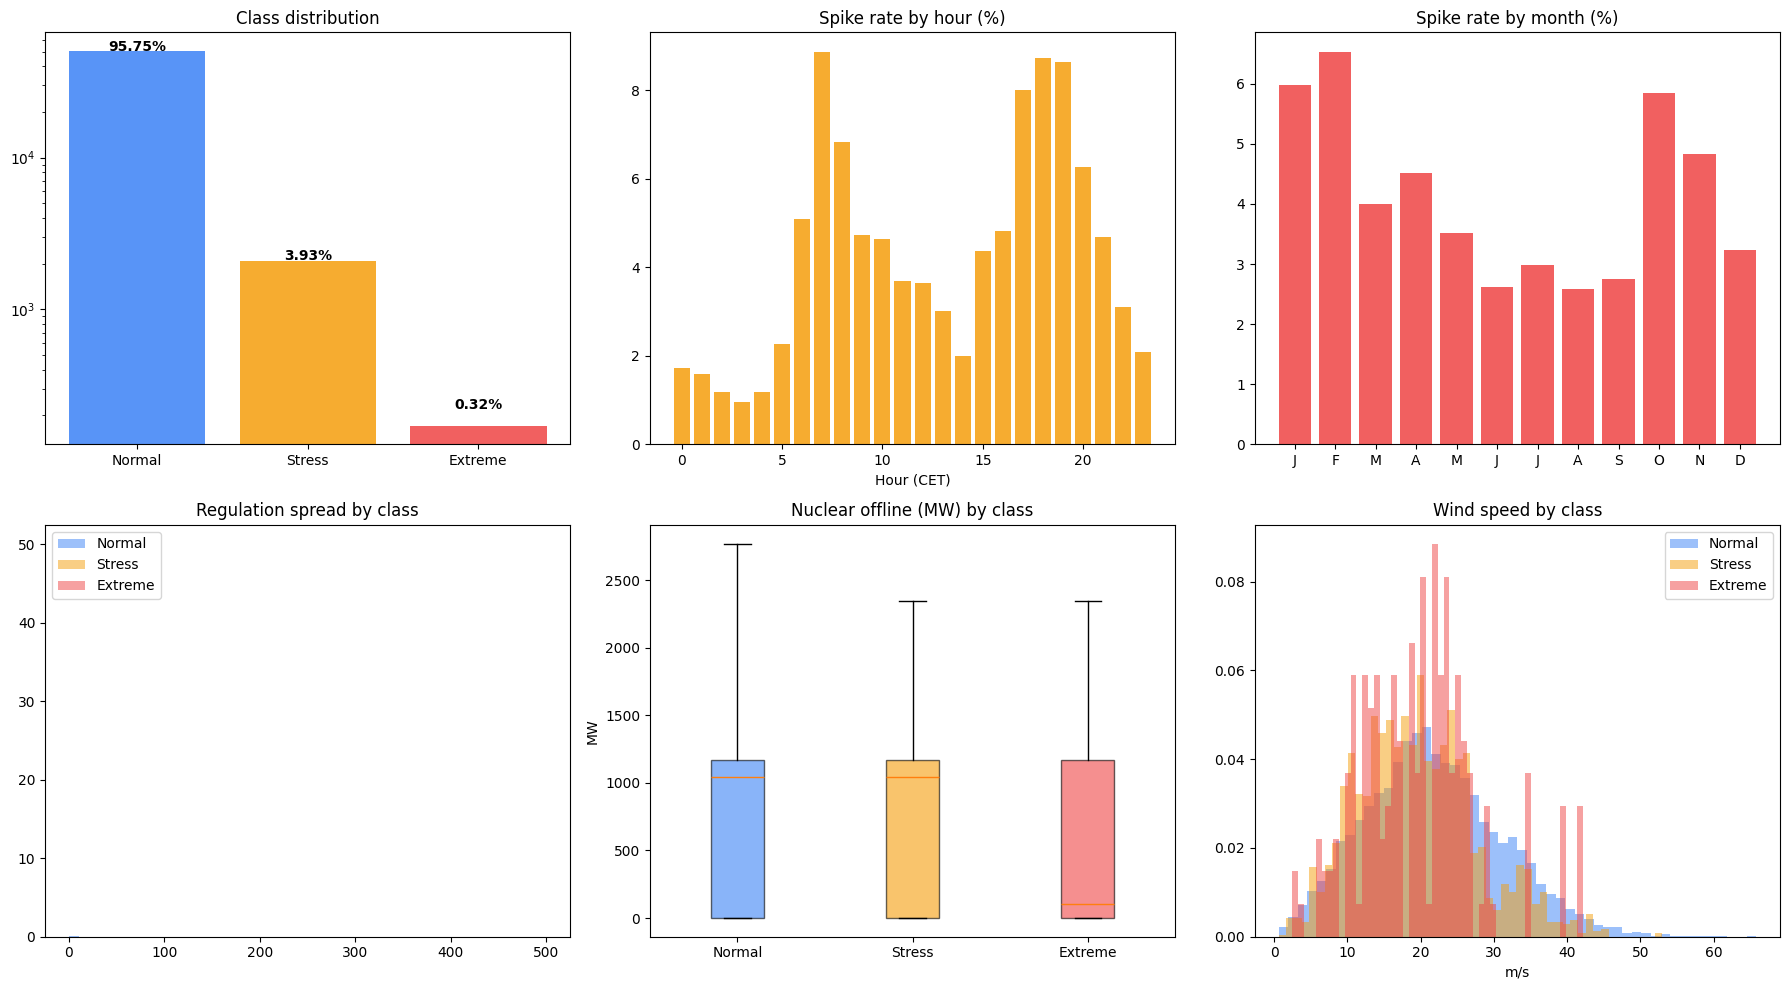

Saved: figures/spike_detection/01_class_eda.png


In [3]:
# ── EDA: class imbalance overview ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
COLORS = {0: "#3b82f6", 1: "#f59e0b", 2: "#ef4444"}

# 1. Class distribution
ax = axes[0, 0]
cc = assign_spike_class(df_merged["imbl_price"]).value_counts().sort_index()
bars = ax.bar([CLASS_NAMES[i] for i in cc.index], cc.values,
              color=[COLORS[i] for i in cc.index], alpha=0.85)
for bar, v in zip(bars, cc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f"{v/len(df_merged)*100:.2f}%", ha="center", fontweight="bold")
ax.set_title("Class distribution"); ax.set_yscale("log")

# 2. Spike rate by hour
ax = axes[0, 1]
df_merged["_spike"] = (assign_spike_class(df_merged["imbl_price"]) > 0).astype(int)
hr_spike = df_merged.groupby(df_merged.index.hour)["_spike"].mean() * 100
ax.bar(hr_spike.index, hr_spike.values, color="#f59e0b", alpha=0.85)
ax.set_title("Spike rate by hour (%)"); ax.set_xlabel("Hour (CET)")

# 3. Spike rate by month
ax = axes[0, 2]
mo_spike = df_merged.groupby(df_merged.index.month)["_spike"].mean() * 100
ax.bar(range(1,13), [mo_spike.get(m,0) for m in range(1,13)], color="#ef4444", alpha=0.85)
ax.set_title("Spike rate by month (%)"); ax.set_xticks(range(1,13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])

# 4. Regulation spread before spike
ax = axes[1, 0]
if "up_reg_price" in df_merged.columns and "down_reg_price" in df_merged.columns:
    reg_spread = (df_merged["up_reg_price"] - df_merged["down_reg_price"]).clip(0, 500)
    for cls, name in CLASS_NAMES.items():
        mask = (assign_spike_class(df_merged["imbl_price"]) == cls)
        ax.hist(reg_spread[mask].dropna(), bins=50, alpha=0.5, label=name,
                color=COLORS[cls], density=True)
    ax.set_title("Regulation spread by class"); ax.legend()
else:
    ax.text(0.5,0.5,"Reg spread N/A",ha="center",va="center",transform=ax.transAxes)
    ax.set_title("Regulation spread")

# 5. Nuclear unavailability by class (if available)
ax = axes[1, 1]
if "nuclear_unavail_mw" in df_merged.columns and df_merged["nuclear_unavail_mw"].notna().any():
    cls_arr = assign_spike_class(df_merged["imbl_price"])
    boxes = [df_merged.loc[cls_arr==c,"nuclear_unavail_mw"].dropna().values for c in [0,1,2]]
    bp = ax.boxplot(boxes, labels=[CLASS_NAMES[c] for c in [0,1,2]],
                    patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], [0,1,2]):
        patch.set_facecolor(COLORS[c]); patch.set_alpha(0.6)
    ax.set_title("Nuclear offline (MW) by class"); ax.set_ylabel("MW")
else:
    ax.text(0.5,0.5,"Nuclear data N/A",ha="center",va="center",transform=ax.transAxes)
    ax.set_title("Nuclear unavailability — N/A")

# 6. Wind before spike
ax = axes[1, 2]
wcol = "windspeed_100m" if "windspeed_100m" in df_merged.columns else "windspeed_10m"
cls_arr = assign_spike_class(df_merged["imbl_price"])
for cls, name in CLASS_NAMES.items():
    vals = df_merged.loc[cls_arr==cls, wcol].dropna()
    if len(vals):
        ax.hist(vals, bins=50, alpha=0.5, label=name, color=COLORS[cls], density=True)
ax.set_title("Wind speed by class"); ax.set_xlabel("m/s"); ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_class_eda.png", dpi=150, bbox_inches="tight")
plt.show()
df_merged.drop(columns=["_spike"], inplace=True)
print("Saved: figures/spike_detection/01_class_eda.png")


In [ ]:
def _feat_breakdown(cols):
    groups = {
        "base_lags":    [c for c in cols if c.startswith("imbl_lag") or c.startswith("imbl_roll") or c == "imbl_ewa"],
        "direction":    [c for c in cols if c.startswith("dir_")],
        "spike":        [c for c in cols if any(k in c for k in ["zscore","stress_prox","consec","momentum","flip_rate","regime_flip","periods_since","imbl_abs","imbl_roll_1h_m","imbl_roll_4h_m","imbl_roll_1h_s","imbl_roll_4h_s"])],
        "calendar":     [c for c in cols if any(k in c for k in ["_sin_k","_cos_k","slot_sin","slot_cos","hour_sin","hour_cos","dow_sin","dow_cos","month_sin","month_cos","season","is_","holiday"])],
        "weather":      [c for c in cols if any(k in c for k in ["wind","temp","cloud","heat","demand","solar_rad"])],
        "fcst":         [c for c in cols if c.startswith("fcst_") or c.startswith("mesan_") or c == "wind_forecast_surprise"],
        "nuclear":      [c for c in cols if c.startswith("nuclear_")],
        "gen_forecast": [c for c in cols if "forecast" in c],
        "flows":        [c for c in cols if c.startswith("flow_") or "net_pos" in c],
        "regulation":   [c for c in cols if "reg_spread" in c or "spot_price" in c or "spot_diff" in c],
    }
    for grp, gcols in groups.items():
        if gcols:
            print(f"  {grp:<16}: {len(gcols)}")
    return groups

print("Building spike features...")
df_feats  = build_features(df_merged, horizon=HORIZON)
df_feats  = df_feats.dropna(axis=1, how="all")
feat_cols = make_feature_cols(df_feats, mode="spike")

# LightGBM handles NaN features natively -- only drop rows where TARGET is missing
core_lags = ["imbl_lag_1", "imbl_lag_2", "imbl_roll_1h_mean"]
df_model  = df_feats.dropna(subset=["target_class", "target_binary"])
df_model  = df_model.dropna(subset=[c for c in core_lags if c in df_model.columns])
df_model["target_class"]  = df_model["target_class"].astype(int)
df_model["target_binary"] = df_model["target_binary"].astype(int)

feat_nan_rate = df_model[feat_cols].isna().mean().mean()
feats_over50  = (df_model[feat_cols].isna().mean() > 0.5).sum()
print(f"Feature matrix: {len(df_model):,} rows x {len(feat_cols)} features")
print(f"Feature NaN rate (mean): {feat_nan_rate:.3f}")
print(f"Features with >50% NaN: {feats_over50}")
if len(df_model) == 0:
    raise RuntimeError("Empty model dataset after cleaning. Check target columns.")
grps = _feat_breakdown(feat_cols)
print("\nClass distribution after cleaning:")
for cls, name in CLASS_NAMES.items():
    n = (df_model["target_class"] == cls).sum()
    print(f"  Class {cls} ({name:<8}): {n:,} ({n/len(df_model)*100:.2f}%)")


In [5]:
# Train / test split
split_date = df_model.index.max() - pd.Timedelta(days=TEST_DAYS)
train_df   = df_model[df_model.index <= split_date]
test_df    = df_model[df_model.index >  split_date]

X_train = train_df[feat_cols].values
y_train = train_df["target_class"].values
X_test  = test_df[feat_cols].values
y_test  = test_df["target_class"].values
y_test_bin = (y_test > 0).astype(int)

print(f"Train: {len(X_train):,} rows  ({train_df.index[0].date()} -> {train_df.index[-1].date()})")
print(f"Test : {len(X_test):,}  rows  ({test_df.index[0].date()} -> {test_df.index[-1].date()})")
print(f"Train spike prevalence: {(y_train > 0).mean()*100:.2f}%")
print(f"Test  spike prevalence: {y_test_bin.mean()*100:.2f}%")


Train: 46,968 rows  (2024-12-05 -> 2026-04-08)
Test : 5,759  rows  (2026-04-08 -> 2026-06-07)
Train spike prevalence: 4.43%
Test  spike prevalence: 2.83%


In [6]:
# ── Window augmentation (±2 periods around real spikes) ──────────────────────
# Validation holdout taken BEFORE augmentation — real distribution, not synthetic
WINDOW = 2
val_n  = max(int(len(X_train) * 0.10), 1000)

# Hold out last val_n REAL samples for early stopping
X_real_val = X_train[-val_n:]
y_real_val = (y_train[-val_n:] > 0).astype(int)
X_train_base = X_train[:-val_n]
y_train_base = y_train[:-val_n]

# Window augmentation on training base only
spike_idx  = np.where(y_train_base > 0)[0]
window_set = set()
for idx in spike_idx:
    for offset in range(-WINDOW, WINDOW + 1):
        w = idx + offset
        if 0 <= w < len(X_train_base):
            window_set.add(w)
window_arr = np.array(sorted(window_set))
X_win = X_train_base[window_arr]
y_win = y_train_base[window_arr]

X_aug = np.vstack([X_train_base, X_win])
y_aug = np.concatenate([y_train_base, y_win])

print(f"After window augmentation: {len(X_aug):,} rows")
print(f"  Spike prevalence in augmented: {(y_aug > 0).mean()*100:.2f}%")

# Clean infinities
X_aug_clean   = np.where(np.isfinite(X_aug),       X_aug,       0.0)
X_val_clean   = np.where(np.isfinite(X_real_val),  X_real_val,  0.0)
X_test_clean  = np.where(np.isfinite(X_test),      X_test,      0.0)
y_aug_bin     = (y_aug > 0).astype(int)


After window augmentation: 46,215 rows
  Spike prevalence in augmented: 8.59%


In [7]:
# ── Train binary LightGBM classifier ─────────────────────────────────────────
# Exact config that produced AUC=0.899 in previous session
print("Training LightGBM binary classifier...")
clf = lgb.LGBMClassifier(
    objective    = "binary",
    class_weight = {0: 1.0, 1: 25.0},
    **LGBM_PARAMS,
)
clf.fit(
    X_aug_clean, y_aug_bin,
    eval_set    = [(X_val_clean, y_real_val)],
    eval_metric = "auc",
    callbacks   = [lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(50)],
)
print(f"Best iteration: {clf.best_iteration_}")
spike_proba = clf.predict_proba(X_test_clean)[:, 1]
print("Training complete.")


Training LightGBM binary classifier...


[50]	valid_0's auc: 0.895731	valid_0's binary_logloss: 0.368681


[100]	valid_0's auc: 0.900023	valid_0's binary_logloss: 0.221244


[150]	valid_0's auc: 0.898391	valid_0's binary_logloss: 0.166957
Best iteration: 101
Training complete.


In [8]:
# ── Evaluate ──────────────────────────────────────────────────────────────────
auc = roc_auc_score(y_test_bin, spike_proba)
print(f"\nAUC-ROC: {auc:.3f}")
print(f"\nSpike probability summary:")
print(f"  Normal — mean={spike_proba[y_test_bin==0].mean():.4f}  p95={np.percentile(spike_proba[y_test_bin==0],95):.4f}")
print(f"  Spike  — mean={spike_proba[y_test_bin==1].mean():.4f}  p50={np.percentile(spike_proba[y_test_bin==1],50):.4f}")

COST_THRESHOLD = COST_FP / (COST_FP + COST_FN)
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_test_bin, spike_proba)
f2_scores  = (5 * prec_curve[:-1] * rec_curve[:-1]) / (4 * prec_curve[:-1] + rec_curve[:-1] + 1e-9)
best_f2_idx = np.argmax(f2_scores)
OPTIMAL_THRESHOLD = pr_thresholds[best_f2_idx]

# Profit curve for profit-optimal threshold
test_prices = test_df["imbl_price"].values[:len(y_test)]
thresholds_sim = np.linspace(0.01, 0.99, 100)
profits = []
for thresh in thresholds_sim:
    pred_s = (spike_proba >= thresh).astype(int)
    tp_val = test_prices[(pred_s==1) & (y_test_bin==1)].clip(0,5000).sum() * 0.25
    fp_cos = ((pred_s==1) & (y_test_bin==0)).sum() * COST_FP * 0.25
    profits.append(tp_val - fp_cos)
profits = np.array(profits)
PROFIT_THRESHOLD = thresholds_sim[np.argmax(profits)]

print(f"\n{'Threshold':<30} {'Recall':>6} {'Prec':>6} {'F2':>6} {'FP':>5} {'FN':>5}")
print("-" * 60)
for label, thresh in [
    ("Default (0.5)",          0.500),
    (f"Cost-sens ({COST_THRESHOLD:.3f})", COST_THRESHOLD),
    (f"Profit-opt ({PROFIT_THRESHOLD:.3f})",  PROFIT_THRESHOLD),
]:
    yp = (spike_proba >= thresh).astype(int)
    r  = recall_score(y_test_bin, yp, zero_division=0)
    pr = precision_score(y_test_bin, yp, zero_division=0)
    f2 = fbeta_score(y_test_bin, yp, beta=2, zero_division=0)
    fp = ((yp==1) & (y_test_bin==0)).sum()
    fn = ((yp==0) & (y_test_bin==1)).sum()
    print(f"{label:<30} {r:>6.3f} {pr:>6.3f} {f2:>6.3f} {fp:>5} {fn:>5}")

# Store profit-optimal metrics
y_pred_profit = (spike_proba >= PROFIT_THRESHOLD).astype(int)
rec_final  = recall_score(y_test_bin, y_pred_profit, zero_division=0)
prec_final = precision_score(y_test_bin, y_pred_profit, zero_division=0)
f2_final   = fbeta_score(y_test_bin, y_pred_profit, beta=2, zero_division=0)



AUC-ROC: 0.898

Spike probability summary:
  Normal — mean=0.1750  p95=0.6518
  Spike  — mean=0.6117  p50=0.6414

Threshold                      Recall   Prec     F2    FP    FN
------------------------------------------------------------
Default (0.5)                   0.650  0.164  0.409   539    57
Cost-sens (0.048)               0.994  0.040  0.173  3874     1
Profit-opt (0.446)              0.730  0.151  0.413   669    44


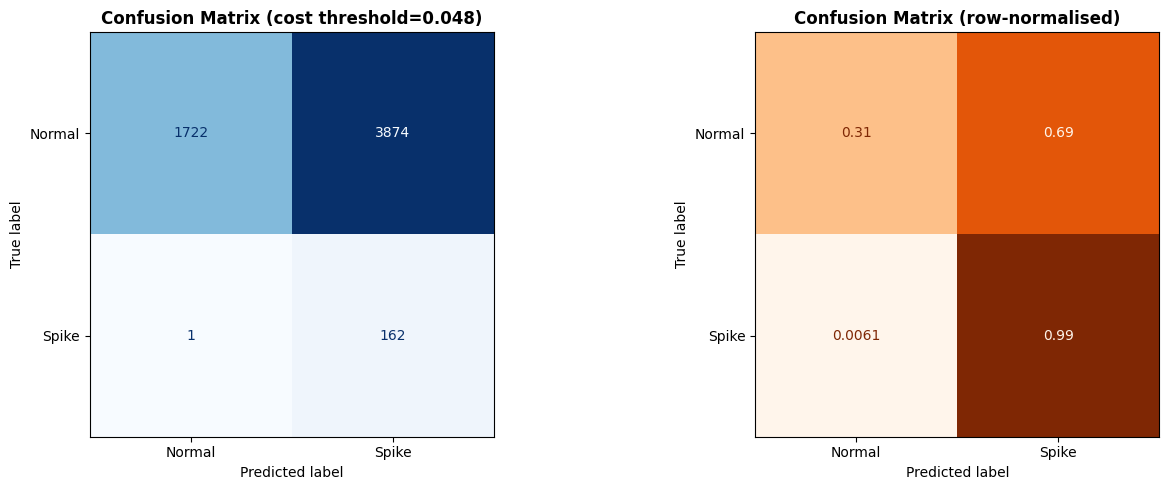

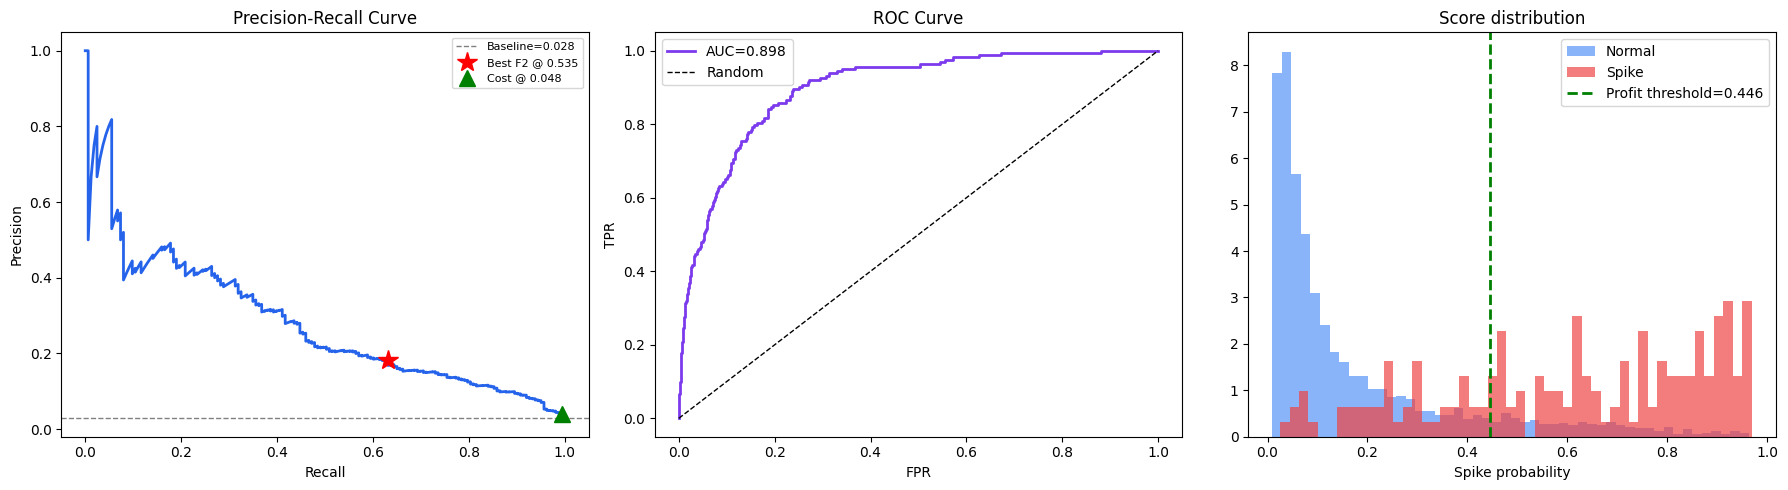

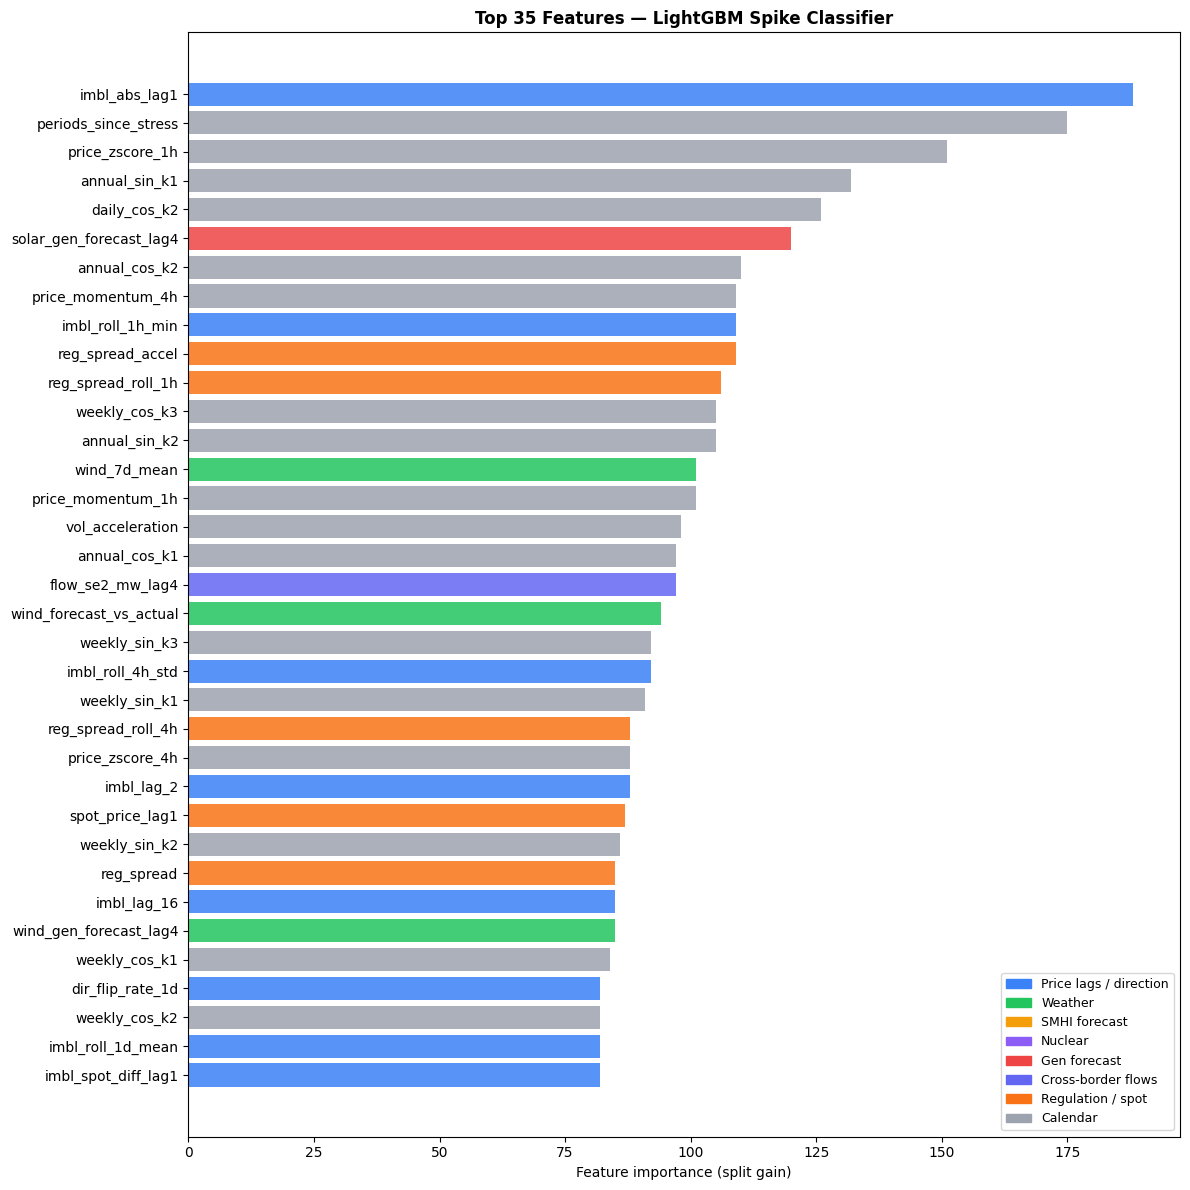

In [9]:
def _src_color(name):
    if name.startswith("imbl_") or name.startswith("dir_"):
        return "#3b82f6"
    if any(k in name for k in ["wind","temp","cloud","heat","demand","solar_rad"]):
        return "#22c55e"
    if name.startswith("smhi_") or name.startswith("mesan_"):
        return "#f59e0b"
    if name.startswith("nuclear_"):
        return "#8b5cf6"
    if "forecast" in name or name.startswith("solar_gen"):
        return "#ef4444"
    if name.startswith("flow_") or "net_pos" in name:
        return "#6366f1"
    if "reg_spread" in name or "spot" in name:
        return "#f97316"
    return "#9ca3af"

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_pred_cost = (spike_proba >= COST_THRESHOLD).astype(int)
cm   = confusion_matrix(y_test_bin, y_pred_cost)
ConfusionMatrixDisplay(cm, display_labels=["Normal","Spike"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix (cost threshold={COST_THRESHOLD:.3f})", fontweight="bold")
cm_n = confusion_matrix(y_test_bin, y_pred_cost, normalize="true")
ConfusionMatrixDisplay(cm_n, display_labels=["Normal","Spike"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Confusion Matrix (row-normalised)", fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "02_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Precision-recall + ROC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(rec_curve, prec_curve, color="#2563eb", lw=2)
axes[0].axhline(y_test_bin.mean(), color="gray", ls="--", lw=1, label=f"Baseline={y_test_bin.mean():.3f}")
axes[0].plot(rec_curve[best_f2_idx], prec_curve[best_f2_idx], "r*", ms=15, label=f"Best F2 @ {OPTIMAL_THRESHOLD:.3f}")
cost_idx = np.argmin(np.abs(pr_thresholds - COST_THRESHOLD))
axes[0].plot(rec_curve[cost_idx], prec_curve[cost_idx], "g^", ms=12, label=f"Cost @ {COST_THRESHOLD:.3f}")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].set_title("Precision-Recall Curve"); axes[0].legend(fontsize=8)

fpr, tpr, _ = roc_curve(y_test_bin, spike_proba)
axes[1].plot(fpr, tpr, color="#7c3aed", lw=2, label=f"AUC={auc:.3f}")
axes[1].plot([0,1],[0,1],"k--",lw=1,label="Random")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("ROC Curve"); axes[1].legend()

norm_proba  = spike_proba[y_test_bin==0]
spike_proba_pos = spike_proba[y_test_bin==1]
axes[2].hist(norm_proba,      bins=50, alpha=0.6, color="#3b82f6", density=True, label="Normal")
axes[2].hist(spike_proba_pos, bins=50, alpha=0.7, color="#ef4444", density=True, label="Spike")
axes[2].axvline(PROFIT_THRESHOLD, color="green", ls="--", lw=2, label=f"Profit threshold={PROFIT_THRESHOLD:.3f}")
axes[2].set_xlabel("Spike probability"); axes[2].set_title("Score distribution"); axes[2].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "03_pr_roc_scores.png", dpi=150, bbox_inches="tight")
plt.show()

# Feature importance
imp   = pd.Series(clf.feature_importances_, index=feat_cols).sort_values()
top35 = imp.tail(35)
fig, ax = plt.subplots(figsize=(12, 12))
ax.barh(top35.index, top35.values, color=[_src_color(n) for n in top35.index], alpha=0.85)
ax.set_title("Top 35 Features — LightGBM Spike Classifier", fontweight="bold")
ax.set_xlabel("Feature importance (split gain)")
handles = [
    mpatches.Patch(color="#3b82f6", label="Price lags / direction"),
    mpatches.Patch(color="#22c55e", label="Weather"),
    mpatches.Patch(color="#f59e0b", label="SMHI forecast"),
    mpatches.Patch(color="#8b5cf6", label="Nuclear"),
    mpatches.Patch(color="#ef4444", label="Gen forecast"),
    mpatches.Patch(color="#6366f1", label="Cross-border flows"),
    mpatches.Patch(color="#f97316", label="Regulation / spot"),
    mpatches.Patch(color="#9ca3af", label="Calendar"),
]
ax.legend(handles=handles, loc="lower right", fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
# ── Walk-forward validation ────────────────────────────────────────────────────
FOLD_DAYS, N_FOLDS = 30, 3
fold_results = []
total_days   = (df_model.index.max() - df_model.index.min()).days
fold_start   = df_model.index.min() + pd.Timedelta(days=total_days - N_FOLDS*FOLD_DAYS - TEST_DAYS)

for fold in range(N_FOLDS):
    fs  = fold_start + pd.Timedelta(days=fold * FOLD_DAYS)
    fe  = min(fs + pd.Timedelta(days=FOLD_DAYS), split_date)
    tr  = df_model[df_model.index < fs]
    te  = df_model[(df_model.index >= fs) & (df_model.index < fe)]
    if len(tr) < 1000 or len(te) < 100:
        continue
    Xtr = np.where(np.isfinite(tr[feat_cols].values), tr[feat_cols].values, 0.0)
    ytr = (tr["target_class"].values > 0).astype(int)
    Xte = np.where(np.isfinite(te[feat_cols].values), te[feat_cols].values, 0.0)
    yte = (te["target_class"].values > 0).astype(int)
    clf_f = lgb.LGBMClassifier(objective="binary", class_weight={0:1.0,1:40.0},
                                n_estimators=500, learning_rate=0.05,
                                num_leaves=63, verbose=-1)
    clf_f.fit(Xtr, ytr)
    proba_f = clf_f.predict_proba(Xte)[:, 1]
    pred_f  = (proba_f >= PROFIT_THRESHOLD).astype(int)
    fold_results.append({
        "fold": fold+1,
        "recall":    recall_score(yte, pred_f, zero_division=0),
        "precision": precision_score(yte, pred_f, zero_division=0),
        "f2":        fbeta_score(yte, pred_f, beta=2, zero_division=0),
        "spike_prev": yte.mean(),
    })
    print(f"Fold {fold+1}: Recall={fold_results[-1]['recall']:.3f}  "
          f"Prec={fold_results[-1]['precision']:.3f}  "
          f"F2={fold_results[-1]['f2']:.3f}  (spike_prev={yte.mean():.3f})")

fr = pd.DataFrame(fold_results)
if len(fr):
    print(f"\nWalk-forward mean: Recall={fr['recall'].mean():.3f}  "
          f"Prec={fr['precision'].mean():.3f}  F2={fr['f2'].mean():.3f}")


Fold 1: Recall=0.446  Prec=0.532  F2=0.461  (spike_prev=0.065)


Fold 2: Recall=0.556  Prec=0.611  F2=0.566  (spike_prev=0.062)


Fold 3: Recall=0.264  Prec=0.368  F2=0.280  (spike_prev=0.018)

Walk-forward mean: Recall=0.422  Prec=0.504  F2=0.436


In [11]:
# ── Summary ────────────────────────────────────────────────────────────────────
src_used = {
    "eSett imbalance":    "imbl_price"          in df_merged.columns,
    "Open-Meteo weather": "temperature"          in df_merged.columns,
    "ENTSO-E spot":       "spot_price"           in df_merged.columns,
    "SMHI forecast":      "smhi_wind_speed"      in df_merged.columns,
    "SMHI analysis":      "mesan_wind_speed"     in df_merged.columns,
    "Nuclear unavail":    "nuclear_unavail_mw"   in df_merged.columns,
    "Gen forecast":       "wind_gen_forecast_mw" in df_merged.columns,
    "Cross-border flows": "net_position_mw"      in df_merged.columns,
}

print("=" * 65)
print("SE3 SPIKE DETECTION -- SUMMARY")
print("=" * 65)
print(f"  Data period  : {df_merged.index.min().date()} -> {df_merged.index.max().date()}")
print(f"  Test set     : last {TEST_DAYS} days ({len(X_test):,} rows)")
print(f"  Features     : {len(feat_cols)} total (spike mode)")
print()
print(f"  AUC-ROC (binary)           : {auc:.3f}")
print(f"  Best iteration             : {clf.best_iteration_}")
print()
print(f"  Profit-optimal threshold   : {PROFIT_THRESHOLD:.4f}")
print(f"  Recall at profit threshold : {rec_final:.3f}")
print(f"  Precision at threshold     : {prec_final:.3f}")
print(f"  F2 at threshold            : {f2_final:.3f}")
print()
if len(fr):
    print(f"  Walk-forward Recall (mean) : {fr['recall'].mean():.3f}")
    print(f"  Walk-forward F2 (mean)     : {fr['f2'].mean():.3f}")
print()
print("  Sources used:")
for src, avail in src_used.items():
    print(f"    {src:<28}: {'YES' if avail else 'no'}")


SE3 SPIKE DETECTION -- SUMMARY
  Data period  : 2024-12-05 -> 2026-06-07
  Test set     : last 60 days (5,759 rows)
  Features     : 117 total (spike mode)

  AUC-ROC (binary)           : 0.898
  Best iteration             : 101

  Profit-optimal threshold   : 0.4456
  Recall at profit threshold : 0.730
  Precision at threshold     : 0.151
  F2 at threshold            : 0.413

  Walk-forward Recall (mean) : 0.422
  Walk-forward F2 (mean)     : 0.436

  Sources used:
    eSett imbalance             : YES
    Open-Meteo weather          : YES
    ENTSO-E spot                : YES
    SMHI forecast               : no
    SMHI analysis               : YES
    Nuclear unavail             : YES
    Gen forecast                : YES
    Cross-border flows          : YES
